# Notebook 03. Triage — 먼저 확인할 업종×분기

## 분석 질문

Q1~Q3 결과 중 어떤 업종×분기를 먼저 확인해야 하는가?

- <b>선행 단계</b> — `02_q1_q2_q3_integrated_analysis.ipynb`에서 상태(Q1)·규모(Q2)·지속(Q3)을 각각 확인했지만, 이 셋을 결합해 확인 순서를 정하는 규칙은 없었다.

## 입력

| 구분 | 경로 |
|---|---|
| Triage 전체 패널 | `outputs/final_model/02_triage/tables/triage_panel.csv` |
| Triage 최신분기 전체 컬럼 | `outputs/final_model/02_triage/tables/triage_latest_full.csv` |
| 규칙 출처 표 | `outputs/final_model/02_triage/tables/triage_rule_provenance.csv` |
| 선택적 재검토 대상 | `outputs/final_model/03_electre_smaa/tables/electre_smaa_review_cases.csv` |

## 출력

<b>Table</b>

이 노트북은 새 표를 저장하지 않는다. 위 산출물을 불러와 규칙과 결과를 검증한다.

<b>Figure</b>

이 노트북은 그림 파일을 저장하지 않는다. 전체 기간 단계 분포와 업종×분기 단계 지도를 노트북 안에서만 표시한다.

## 구성

| 파트 | 내용 | 성격 |
|---|---|---|
| 1단계 | 산출물 불러오기와 키 일치 검증 | 확증 |
| 2단계 | 신호 정의·산식·출처 성격 | 확증 |
| 3단계 | 단계 규칙과 규칙 상수 | 확증 |
| 4단계 | 전체 기간 분포와 업종×분기 지도 | 확증 |
| 5단계 | 최신분기 결과와 주요 사례 | 확증 |
| 6단계 | 추가확인 → 선택적 ELECTRE/SMAA 입력 검증 | 확증 |

## 전체 수행 흐름

1. Triage 산출물과 규칙 출처 표를 불러오고 추가확인↔ELECTRE 입력 키를 검증한다.
2. E/R/A/P 신호의 정의·산식·threshold·출처 성격을 읽는다.
3. 진입·상위·보강 신호와 300인 gate로 이어지는 단계 규칙과 규칙 상수를 확인한다.
4. 전체 기간 단계 분포와 업종×분기 단계 지도를 본다.
5. 최신분기 결과와 우선점검·추가확인 주요 사례를 본다.
6. 추가확인 35건이 선택적 ELECTRE/SMAA 입력과 정확히 일치하는지 검증한다.

```text
Q1 State + Q2 Scale + Q3 Time
                ↓
              Triage
     ┌──────────┼────────────┐
   관찰       추가확인       우선점검
정기 모니터링   │          외부근거·담당자 검토
 ELECTRE X      ↓             ELECTRE X
        선택적 ELECTRE/SMAA
                ↓
          Human-in-the-Loop
```

## 1단계. 환경 설정과 산출물 불러오기

### 무엇을 준비하나

표시용 함수(`show_table`, `show_records`)와 단계별 색상을 정의한다. 이어서 Triage 전체 패널, 최신분기 전체 컬럼, 규칙 출처 표, 선택적 재검토 대상을 불러오고 추가확인 건수와 재검토 대상 키가 일치하는지 확인한다.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir())
sys.path.insert(0, str(ROOT / 'src'))
from utils import notebook_config as config
from core.analysis.config import setup_matplotlib
setup_matplotlib()
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)

def _md_value(value):
    if pd.isna(value): return '—'
    if isinstance(value, (float, np.floating)): return f'{value:,.2f}'
    return str(value).replace('|', '\\|').replace('\n', ' / ')

def show_table(frame, max_rows=30):
    view=frame.head(max_rows)
    header='| '+' | '.join(map(str,view.columns))+' |'
    rule='| '+' | '.join(['---']*len(view.columns))+' |'
    rows=['| '+' | '.join(_md_value(v) for v in row)+' |' for row in view.itertuples(index=False,name=None)]
    note=f'\n\n*상위 {max_rows}행만 표시*' if len(frame)>max_rows else ''
    display(Markdown('\n'.join([header,rule,*rows])+note))

def show_records(frame, title_col, fields=None, max_rows=30):
    fields=fields or [c for c in frame.columns if c!=title_col]
    blocks=[]
    for _, row in frame.head(max_rows).iterrows():
        blocks.append('#### '+_md_value(row[title_col]))
        blocks.extend(f'- **{c}:** {_md_value(row[c])}' for c in fields)
    if len(frame)>max_rows: blocks.append(f'*상위 {max_rows}건만 표시*')
    display(Markdown('\n\n'.join(blocks)))

STAGE_ORDER = ['관찰', '추가확인', '우선점검', '자료확인']
STAGE_COLORS = {'관찰':'#7895A8', '추가확인':'#D39A2C', '우선점검':'#C5523F', '자료확인':'#777777'}
STATE_ORDER = ['S1', 'S2', 'S3', 'S4', 'N', 'INVALID']
STATE_COLORS = {'S1':'#4C78A8','S2':'#72B7B2','S3':'#F2CF5B','S4':'#B279A2','N':'#BDBDBD','INVALID':'#F2F2F2'}

In [2]:
triage = pd.read_csv(config.TRIAGE_PANEL_PATH, encoding='utf-8-sig')
latest = pd.read_csv(config.TRIAGE_LATEST_FULL_PATH, encoding='utf-8-sig')
rules = pd.read_csv(config.TRIAGE_RULE_PROVENANCE_PATH, encoding='utf-8-sig')
review = pd.read_csv(config.ELECTRE_REVIEW_PATH, encoding='utf-8-sig')
check_keys = set(map(tuple, triage.loc[triage.stage.eq('추가확인'), ['industry','quarter']].to_numpy()))
review_keys = set(map(tuple, review[['industry','quarter']].to_numpy()))
assert len(triage) == 180 and check_keys == review_keys and len(check_keys) == 35
assert review.triage_stage_preserved.eq('추가확인').all()
latest_q = triage.quarter.max()
print(f'전체 {len(triage)}건 | 최신 {latest_q} | 추가확인↔ELECTRE 입력 키 일치: {len(check_keys)}건')

전체 180건 | 최신 2026Q2 | 추가확인↔ELECTRE 입력 키 일치: 35건


### 확인 결과

- 전체 패널은 180건이며 기간은 2022Q1~2026Q2다.
- 최신분기는 2026Q2다.
- 추가확인 35건과 선택적 재검토 대상 35건의 `(quarter, industry)` 키가 정확히 같다.

## 2단계. 신호 정의·산식·출처 성격

### 왜 이걸 보나

`PRINCIPLE_ADAPTED`는 외부 기준의 원리를 자료 단위와 목적에 맞게 변형한 값이고, `PROJECT_OPERATIONAL`은 프로젝트 자체 운영기준이다. 이 저장소에는 단위·기간·목적이 모두 같은 직접 공식 threshold(DIRECT_OFFICIAL)가 없다.

In [3]:
rule_view = rules[['rule_name','definition','threshold','role','source_category','source_note']].copy()
rule_view.columns=['신호/규칙','정의·산식','threshold','역할','출처 성격','적용상 주의']
show_records(rule_view,'신호/규칙',['정의·산식','threshold','역할','출처 성격','적용상 주의'])

#### E

- **정의·산식:** max(0, -KICOX 분기말 고용 YoY)

- **threshold:** 5% / 10%

- **역할:** 고용 진입·상위 신호

- **출처 성격:** PRINCIPLE_ADAPTED

- **적용상 주의:** 2026.5.4 시행 고용위기지역 고시 제3조①2호 5%, ④2호 10% 확인. 지역 피보험자 최근 6개월 평균을 업종 종사자 분기말 YoY로 변경. 다른 법정 결합요건·심의절차를 재현하지 않음.

#### R_entry

- **정의·산식:** max(0, 산단 제조업 전체 YoY - 업종 YoY)

- **threshold:** 5%p

- **역할:** 상대 열위 진입

- **출처 성격:** PRINCIPLE_ADAPTED

- **적용상 주의:** 공식 비교는 모든 업종 피보험자 평균. 본 모형은 동일 산단 제조업 10개 업종 합계와 비교.

#### R_up

- **정의·산식:** R과 동일

- **threshold:** 10%p

- **역할:** 상대 열위 상위

- **출처 성격:** PROJECT_OPERATIONAL

- **적용상 주의:** 10%p 상위 경계의 직접 조문 근거 없음. 진입 경계와 출처 분리.

#### A

- **정의·산식:** max(0, 전년동기 고용 - 현재 고용) / 현재 산단 제조업 고용 × 100

- **threshold:** 1% / 2%

- **역할:** 규모효과 진입·상위

- **출처 성격:** PROJECT_OPERATIONAL

- **적용상 주의:** 현재 산단 고용 100명당 전년동기 대비 감소인원 1/2명에 해당. 최적값·정책기준 아님. 대형 업종 영향 큼.

#### P

- **정의·산식:** max(0, -명목 분기 생산액 YoY)

- **threshold:** 5%

- **역할:** 상위단계 보강

- **출처 성격:** PRINCIPLE_ADAPTED

- **적용상 주의:** 현행 제2조는 전년 및 전전년 동기 생산액/생산량 등 결합요건. 본 모형은 명목 생산액 전년동기 비교만 사용하며 가격·물량 분해 불가.

#### repeated_employment_entry_signal

- **정의·산식:** 현재 및 실제 직전 달력분기에 E/R/A 진입신호 존재

- **threshold:** 연속 2분기

- **역할:** Q3 시간축 보강

- **출처 성격:** PRINCIPLE_ADAPTED

- **적용상 주의:** 지속성 원리 참고. 고시 월별 지속요건, 기존 g4 음의 고용 YoY 연속길이, 동일 Q1 상태 run_length와 모두 다름.

#### scale_gate

- **정의·산식:** 현재 업종 고용이 기준 이상

- **threshold:** 300인

- **역할:** 우선점검 진입만 제한

- **출처 성격:** PRINCIPLE_ADAPTED

- **적용상 주의:** 공식 주된 산업의 비중·종사자 요건 중 규모 원리만 참고한 운영규칙. 추가확인 신호 보존. 300인 최적성 미입증.

#### ladder

- **정의·산식:** 상위 고용신호 AND (P OR 반복) AND 규모; 아니면 진입신호

- **threshold:** 관찰 / 추가확인 / 우선점검

- **역할:** 행동단계

- **출처 성격:** PROJECT_OPERATIONAL

- **적용상 주의:** 법정 지정의 결합식이 아니라 내부 점검 사다리.

#### missing

- **정의·산식:** 핵심 E/R/A·고용 미확인 시 판정보류; P만 없으면 알려진 신호로 최소판정

- **threshold:** 보간 없음

- **역할:** 자료품질

- **출처 성격:** PROJECT_OPERATIONAL

- **적용상 주의:** 미확인 보강조건은 충족으로 간주하지 않음. 최소판정과 자료 플래그 함께 전달.

#### same_stage_rank

- **정의·산식:** 같은 분기·단계에서 감소인원 내림차순, 동률 업종명

- **threshold:** 감소인원

- **역할:** 처리순서

- **출처 성격:** PROJECT_OPERATIONAL

- **적용상 주의:** Q2 전체 점수화 아님. 동률 순서는 위험 우열이 아닌 결정적 표시순서.

### 관찰 결과

- 규칙은 총 10개다. 이 중 5개(E, R_entry, P, 반복신호, 규모gate)는 PRINCIPLE_ADAPTED, 나머지 5개(R_up, A, ladder, missing, same_stage_rank)는 PROJECT_OPERATIONAL이다.

### 해석

- PRINCIPLE_ADAPTED는 선제대응·특별고용지원업종 등 외부 제도의 수준·규모·지속 개념을 자료 단위에 맞게 옮긴 것이고, PROJECT_OPERATIONAL은 조문 근거 없이 프로젝트가 정한 값이다.

> 주의: 이 구분은 threshold가 옳다는 근거가 아니라 threshold의 출처만 밝힌다.

## 3단계. 실제 단계 규칙과 규칙 상수

### 어떻게 정의했나

```text
진입신호 = E≥5% 또는 R≥5%p 또는 A≥1%
상위신호 = E≥10% 또는 R≥10%p 또는 A≥2%
보강신호 = P≥5% 또는 직전분기에도 진입신호

우선점검 = 상위신호 AND 보강신호 AND 현재 고용≥300명
추가확인 = 진입신호는 있으나 우선점검 조건이 완결되지 않음
관찰     = 고용축 진입신호 없음
```

P는 단독으로 단계에 진입시키지 않으며, 300인 gate는 우선점검만 제한한다. 작은 업종의 고용 신호를 삭제하지 않고 추가확인에 남긴다.

In [4]:
import inspect
from triage import triage_rule as tr

const_names = ['LEVEL_ENTRY', 'LEVEL_UP', 'REL_ENTRY', 'REL_UP', 'ABS_ENTRY', 'ABS_UP', 'PROD_SUPPORT', 'SCALE_MIN']
src_lines = inspect.getsource(tr).splitlines()
rows = []
for name in const_names:
    line = next(l for l in src_lines if l.strip().startswith(name + ' ='))
    comment = line.split('#', 1)[1].strip() if '#' in line else ''
    tag = comment.split(':', 1)[0].strip() if ':' in comment else comment
    note = comment.split(':', 1)[1].strip() if ':' in comment else ''
    rows.append({'상수': name, '값': getattr(tr, name), '출처 성격': tag, '비고': note})
const_table = pd.DataFrame(rows)
show_table(const_table)
print('RULE_VERSION:', tr.RULE_VERSION)

| 상수 | 값 | 출처 성격 | 비고 |
| --- | --- | --- | --- |
| LEVEL_ENTRY | 5.00 | PRINCIPLE_ADAPTED | 피보험자·이동평균과 KICOX 분기말 고용은 다름 |
| LEVEL_UP | 10.00 | PRINCIPLE_ADAPTED | 법정 지역 지정이 아닌 내부 업종 점검 |
| REL_ENTRY | 5.00 | PRINCIPLE | 특별고용지원업종 제2조①1호(전국평균 대비 5%p) → 산단 제조업 평균 대비 |
| REL_UP | 10.00 | OWN | 조문에 상위 %p 기준 없음 |
| ABS_ENTRY | 1.00 | OWN | 고용 감소인원 ÷ 산단 제조업 고용 |
| ABS_UP | 2.00 | OWN |  |
| PROD_SUPPORT | 5.00 | PRINCIPLE | 선제대응 제2조③3호 생산액 5% |
| SCALE_MIN | 300.00 | PRINCIPLE | 선제대응 제2조①2호 '종사자 300인 이상' → 우선점검 진입요건으로만 |

RULE_VERSION: changwon-triage-rule/3.1.0-audited


### 관찰 결과

- LEVEL_ENTRY·LEVEL_UP(5%/10%), REL_ENTRY(5%p), PROD_SUPPORT(5%), SCALE_MIN(300인)은 PRINCIPLE 또는 PRINCIPLE_ADAPTED로, 선제대응·특별고용지원업종 조문의 수준·규모 원리를 참고했다.
- REL_UP(10%p)·ABS_ENTRY(1%)·ABS_UP(2%)은 OWN으로, 조문에 대응 근거가 없는 프로젝트 자체 값이다.
- RULE_VERSION은 `changwon-triage-rule/3.1.0-audited`다.

### Decision Box — 300인 gate를 왜 우선점검 진입에만 거는가

- **문제:** 상위신호와 보강신호를 모두 만족해도 업종 고용 규모가 작으면 그 변화가 산단 제조업 전체에서 차지하는 비중은 작다. 규모를 어느 단계에서 걸러야 하는가.
- **선택:** `SCALE_MIN=300`(현재 고용 300명 미만)은 <b>우선점검 진입만</b> 제한한다(`gate='priority_gate'`). 추가확인 진입 조건에는 넣지 않는다.
- **근거:** `src/triage/triage_rule.py`의 `SCALE_MIN = 300  # PRINCIPLE: 선제대응 제2조①2호 '종사자 300인 이상' → 우선점검 진입요건으로만`. 같은 파일 `apply_rule` 함수에서도 `gate == 'priority_gate' and not scale_ok`일 때만 우선점검 여부(`pri`)를 낮추고, 추가확인 판정(`emp_entry`)은 규모와 무관하게 그대로 남는다.
- **결론에 미친 영향:** 이 gate 때문에 상위·보강 신호를 모두 만족해도 고용 규모가 작은 업종은 우선점검이 아니라 추가확인으로 남는다. gate를 없애거나 기준을 바꿨을 때 우선점검·추가확인 수가 실제로 얼마나 바뀌는지는 `04_model_evolution_and_experiments.ipynb`의 민감도 분석에서 공개한다.

## 4단계. 전체 기간 분포와 업종×분기 지도

### 왜 이걸 보나

단계 규칙을 2022Q1~2026Q2 전체 180건에 적용하면 어떤 분포가 나오는지, 같은 업종이 분기마다 어떻게 이동하는지를 본다.

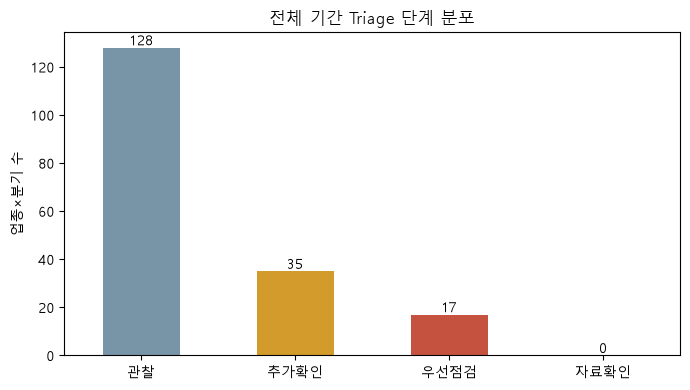

In [5]:
dist = triage.stage.value_counts().reindex(STAGE_ORDER,fill_value=0)
ax = dist.plot.bar(color=[STAGE_COLORS[s] for s in dist.index],figsize=(7,4)); ax.set_title('전체 기간 Triage 단계 분포'); ax.set_xlabel(''); ax.set_ylabel('업종×분기 수')
for p in ax.patches: ax.text(p.get_x()+p.get_width()/2,p.get_height()+1,int(p.get_height()),ha='center')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


### 관찰 결과

- 전체 180건은 관찰 128건, 추가확인 35건, 우선점검 17건이다.

### 해석

- Triage는 전체를 다시 등급화하는 위험점수가 아니라 확인 강도를 세 단계로 나누는 운영 사다리다.

> 주의: 분포 자체는 threshold의 정책 타당성을 증명하지 않는다.

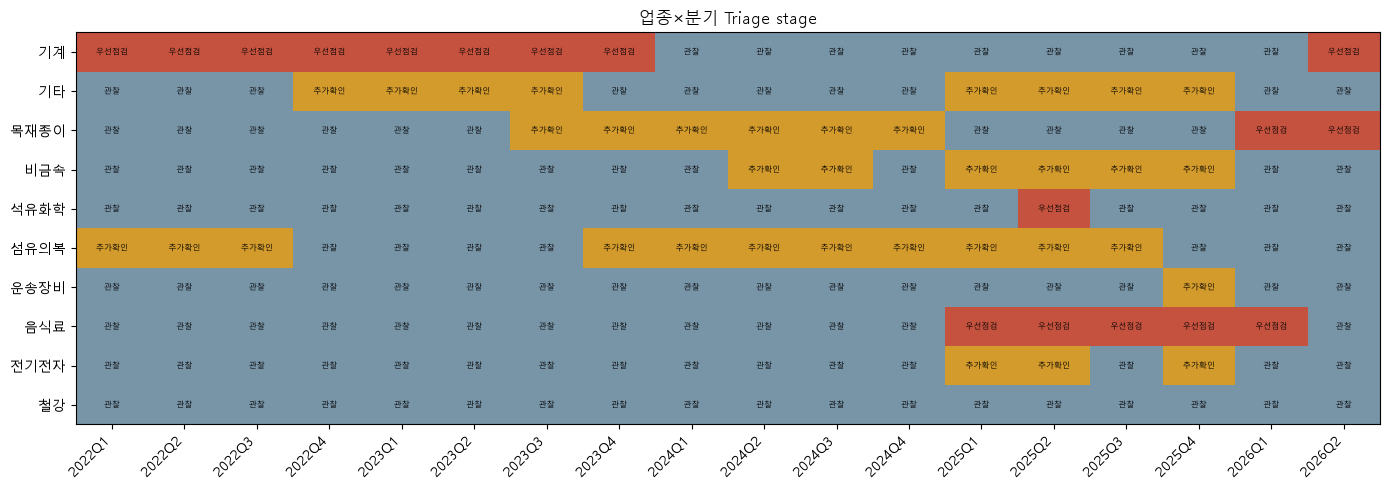

In [6]:
grid = triage.pivot(index='industry',columns='quarter',values='stage'); stage_map={s:i for i,s in enumerate(STAGE_ORDER)}
from matplotlib.colors import ListedColormap
z=grid.map(lambda x: stage_map.get(x,3)).to_numpy(); fig,ax=plt.subplots(figsize=(14,5))
ax.imshow(z,aspect='auto',cmap=ListedColormap([STAGE_COLORS[s] for s in STAGE_ORDER]),vmin=0,vmax=3)
ax.set_xticks(range(len(grid.columns)),grid.columns,rotation=45,ha='right'); ax.set_yticks(range(len(grid.index)),grid.index)
for i in range(z.shape[0]):
    for j in range(z.shape[1]): ax.text(j,i,grid.iloc[i,j],ha='center',va='center',fontsize=6)
ax.set_title('업종×분기 Triage stage'); plt.tight_layout(); plt.show()


### 관찰 결과

- 단계는 업종별로 고정되지 않고 분기마다 이동한다.

### 해석

- 이 구조는 업종 낙인이나 영구 순위가 아니라 분기별 확인 큐에 가깝다.

> 주의: 과거 우선점검 이력은 해당 시점의 집계신호이며 실제 위기 발생의 사후 라벨이 아니다.

## 5단계. 최신분기 결과와 주요 사례

### 왜 이걸 보나

가장 최근 분기(2026Q2)에 어떤 업종이 어떤 단계이고 무슨 신호로 그렇게 판정됐는지, 최근 우선점검·추가확인 이력은 어땠는지를 본다.

In [7]:
latest = latest.copy(); latest['triggered_signals'] = latest.decision_entry_trigger + ' / 보강:' + latest.decision_reinforcement
latest['electre_review_required'] = latest.stage.eq('추가확인')
cols=['industry','quarter','stage','triggered_signals','emp_delta','e_yoy','A','run_length','stage_reason','electre_review_required']
view=latest.sort_values(['stage','rank_in_stage'])[cols]; view.columns=['업종','분기','단계','발동신호','고용증감(명)','고용YoY(%)','A(%)','상태지속(Q)','선정 이유','ELECTRE 재검토']
show_table(view.round(2))
priority_or_check = triage.loc[triage.stage.isin(['우선점검','추가확인'])].sort_values(['quarter','stage','rank_in_stage'])
show_table(priority_or_check.tail(15)[['quarter','industry','stage','decision_entry_trigger','decision_reinforcement','stage_reason']])

| 업종 | 분기 | 단계 | 발동신호 | 고용증감(명) | 고용YoY(%) | A(%) | 상태지속(Q) | 선정 이유 | ELECTRE 재검토 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 운송장비 | 2026Q2 | 관찰 | 없음 / 보강:확인된 보강 없음 | -129.00 | -0.78 | 0.11 | 2.00 | 고용 축 진입신호 없음 | False |
| 전기전자 | 2026Q2 | 관찰 | 없음 / 보강:확인된 보강 없음 | -116.00 | -0.41 | 0.10 | 1.00 | 고용 축 진입신호 없음 | False |
| 철강 | 2026Q2 | 관찰 | 없음 / 보강:확인된 보강 없음 | -112.00 | -1.14 | 0.10 | 4.00 | 고용 축 진입신호 없음 | False |
| 음식료 | 2026Q2 | 관찰 | 없음 / 보강:확인된 보강 없음 | -25.00 | -3.79 | 0.02 | 2.00 | 고용 축 진입신호 없음 | False |
| 비금속 | 2026Q2 | 관찰 | 없음 / 보강:확인된 보강 없음 | -2.00 | -1.08 | 0.00 | 3.00 | 고용 축 진입신호 없음 | False |
| 기타 | 2026Q2 | 관찰 | 없음 / 보강:확인된 보강 없음 | 25.00 | 17.12 | 0.00 | 2.00 | 고용 축 진입신호 없음 | False |
| 석유화학 | 2026Q2 | 관찰 | 없음 / 보강:생산 | 54.00 | 9.56 | 0.00 | 1.00 | 고용 축 진입신호 없음 (생산 6.7% 단독 감소 — 확인질문에 반영) | False |
| 섬유의복 | 2026Q2 | 관찰 | 없음 / 보강:생산 | 0.00 | 0.00 | 0.00 | — | 고용 축 진입신호 없음 (생산 12.3% 단독 감소 — 확인질문에 반영) | False |
| 기계 | 2026Q2 | 우선점검 | E\|A / 보강:생산 | -3,979.00 | -6.34 | 3.47 | 2.00 | 고용감소 6.3%(진입경계 5% 통과) · 산단 제조업 고용의 3.47% 감소(상위경계 2.0% 통과) → 보강: 생산 19.5% 감소 | False |
| 목재종이 | 2026Q2 | 우선점검 | E\|R / 보강:생산\|반복 | -48.00 | -10.08 | 0.04 | 2.00 | 고용감소 10.1%(상위경계 10% 통과) · 산단평균 대비 6.4%p 열위(진입경계 통과) → 보강: 생산 12.9% 감소 / 직전 분기에도 진입신호(지속) | False |

| quarter | industry | stage | decision_entry_trigger | decision_reinforcement | stage_reason |
| --- | --- | --- | --- | --- | --- |
| 2025Q2 | 기타 | 추가확인 | E\|R | 반복 | 고용감소 15.6%(상위경계 10% 통과) · 산단평균 대비 18.1%p 열위(상위경계 통과) [상위경계 통과했으나 고용 146인 < 300인으로 우선점검 제외] |
| 2025Q2 | 섬유의복 | 추가확인 | E\|R | 반복 | 고용감소 10.5%(상위경계 10% 통과) · 산단평균 대비 13.0%p 열위(상위경계 통과) [상위경계 통과했으나 고용 34인 < 300인으로 우선점검 제외] |
| 2025Q3 | 음식료 | 우선점검 | E\|R | 생산\|반복 | 고용감소 28.4%(상위경계 10% 통과) · 산단평균 대비 28.5%p 열위(상위경계 통과) → 보강: 생산 17.5% 감소 / 직전 분기에도 진입신호(지속) |
| 2025Q3 | 비금속 | 추가확인 | E\|R | 생산\|반복 | 고용감소 22.9%(상위경계 10% 통과) · 산단평균 대비 23.1%p 열위(상위경계 통과) [상위경계 통과했으나 고용 182인 < 300인으로 우선점검 제외] |
| 2025Q3 | 기타 | 추가확인 | E\|R | 반복 | 고용감소 16.2%(상위경계 10% 통과) · 산단평균 대비 16.4%p 열위(상위경계 통과) [상위경계 통과했으나 고용 145인 < 300인으로 우선점검 제외] |
| 2025Q3 | 섬유의복 | 추가확인 | E\|R | 생산\|반복 | 고용감소 10.5%(상위경계 10% 통과) · 산단평균 대비 10.7%p 열위(상위경계 통과) [상위경계 통과했으나 고용 34인 < 300인으로 우선점검 제외] |
| 2025Q4 | 음식료 | 우선점검 | E\|R | 생산\|반복 | 고용감소 32.6%(상위경계 10% 통과) · 산단평균 대비 33.4%p 열위(상위경계 통과) → 보강: 생산 15.3% 감소 / 직전 분기에도 진입신호(지속) |
| 2025Q4 | 전기전자 | 추가확인 | R\|A | 확인된 보강 없음 | 산단평균 대비 5.5%p 열위(진입경계 통과) · 산단 제조업 고용의 1.20% 감소(진입경계 1.0% 통과) |
| 2025Q4 | 운송장비 | 추가확인 | E\|R | 생산 | 고용감소 5.3%(진입경계 5% 통과) · 산단평균 대비 6.1%p 열위(진입경계 통과) |
| 2025Q4 | 비금속 | 추가확인 | E\|R | 반복 | 고용감소 27.6%(상위경계 10% 통과) · 산단평균 대비 28.4%p 열위(상위경계 통과) [상위경계 통과했으나 고용 178인 < 300인으로 우선점검 제외] |
| 2025Q4 | 기타 | 추가확인 | E\|R | 반복 | 고용감소 27.0%(상위경계 10% 통과) · 산단평균 대비 27.8%p 열위(상위경계 통과) [상위경계 통과했으나 고용 143인 < 300인으로 우선점검 제외] |
| 2026Q1 | 음식료 | 우선점검 | E\|R | 반복 | 고용감소 21.5%(상위경계 10% 통과) · 산단평균 대비 19.8%p 열위(상위경계 통과) → 보강: 직전 분기에도 진입신호(지속) |
| 2026Q1 | 목재종이 | 우선점검 | E\|R | 생산 | 고용감소 10.6%(상위경계 10% 통과) · 산단평균 대비 9.0%p 열위(진입경계 통과) → 보강: 생산 14.3% 감소 |
| 2026Q2 | 기계 | 우선점검 | E\|A | 생산 | 고용감소 6.3%(진입경계 5% 통과) · 산단 제조업 고용의 3.47% 감소(상위경계 2.0% 통과) → 보강: 생산 19.5% 감소 |
| 2026Q2 | 목재종이 | 우선점검 | E\|R | 생산\|반복 | 고용감소 10.1%(상위경계 10% 통과) · 산단평균 대비 6.4%p 열위(진입경계 통과) → 보강: 생산 12.9% 감소 / 직전 분기에도 진입신호(지속) |

### 관찰 결과

- 2026Q2는 우선점검 2개 업종(기계, 목재종이), 관찰 8건이며 추가확인은 없다. 과거 기간 전체에서는 추가확인 35건이 존재한다.
- 기계는 고용 58,784명, 증감 -3,979명, 고용YoY -6.34%, A 3.47%, 상태지속 2분기다.
- 목재종이는 고용 428명, 증감 -48명, 고용YoY -10.08%, A 0.042%, 상태지속 2분기다.

### 해석

- 최신분기 우선점검은 ELECTRE를 거치지 않고 외부근거·담당자 검토로 이동한다. 추가확인은 기준 간 경계와 미완결 조건을 사람이 다시 볼 수 있도록 선택적 다기준 재검토로 보낸다.

> 주의: 최신분기 추가확인이 0건이라는 사실은 ELECTRE 경로가 불필요하다는 뜻이 아니라, 이번 분기에는 해당 경로로 들어갈 사례가 없다는 뜻이다.

## 6단계. 추가확인 → 선택적 ELECTRE/SMAA 입력 검증

### 왜 이걸 보나

추가확인 35건이 선택적 ELECTRE/SMAA 재검토 대상과 정확히 같은 사례인지, 그 결과가 Triage 단계를 덮어쓰지 않는지를 확인한다.

In [8]:
entry = triage.loc[triage.stage.eq('추가확인'), ['quarter','industry','stage','decision_entry_trigger','decision_reinforcement','stage_reason']].copy()
entry['electre_review_required']=True
entry=entry.merge(review[['quarter','industry','electre_stage','possible_stages','n_possible','smaa_parameter_sensitive','boundary_action']],on=['quarter','industry'],how='left',validate='one_to_one')
assert entry.electre_stage.notna().all(); show_table(entry.head(20))
print('Triage 추가확인:',len(entry),'| ELECTRE 결과:',entry.electre_stage.value_counts().to_dict(),'| SMAA 파라미터 민감:',int(entry.smaa_parameter_sensitive.sum()))

| quarter | industry | stage | decision_entry_trigger | decision_reinforcement | stage_reason | electre_review_required | electre_stage | possible_stages | n_possible | smaa_parameter_sensitive | boundary_action |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 2022Q1 | 섬유의복 | 추가확인 | E\|R | 반복 | 고용감소 11.4%(상위경계 10% 통과) · 산단평균 대비 11.6%p 열위(상위경계 통과) [상위경계 통과했으나 고용 39인 < 300인으로 우선점검 제외] | True | OBSERVE | OBSERVE\|CHECK | 2 | True | Triage-ELECTRE 불일치 확인(관찰로 자동 하향하지 않음) |
| 2022Q2 | 섬유의복 | 추가확인 | E\|R | 반복 | 고용감소 11.4%(상위경계 10% 통과) · 산단평균 대비 11.3%p 열위(상위경계 통과) [상위경계 통과했으나 고용 39인 < 300인으로 우선점검 제외] | True | CHECK | OBSERVE\|CHECK | 2 | True | 추가확인 유지 |
| 2022Q3 | 섬유의복 | 추가확인 | E\|R | 반복 | 고용감소 11.4%(상위경계 10% 통과) · 산단평균 대비 11.1%p 열위(상위경계 통과) [상위경계 통과했으나 고용 39인 < 300인으로 우선점검 제외] | True | CHECK | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인 유지 |
| 2022Q4 | 기타 | 추가확인 | E\|R | 생산 | 고용감소 19.4%(상위경계 10% 통과) · 산단평균 대비 16.5%p 열위(상위경계 통과) [상위경계 통과했으나 고용 158인 < 300인으로 우선점검 제외] | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2023Q1 | 기타 | 추가확인 | E\|R | 생산\|반복 | 고용감소 24.6%(상위경계 10% 통과) · 산단평균 대비 21.6%p 열위(상위경계 통과) [상위경계 통과했으나 고용 147인 < 300인으로 우선점검 제외] | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2023Q2 | 기타 | 추가확인 | E\|R | 생산\|반복 | 고용감소 18.6%(상위경계 10% 통과) · 산단평균 대비 15.6%p 열위(상위경계 통과) [상위경계 통과했으나 고용 158인 < 300인으로 우선점검 제외] | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2023Q3 | 기타 | 추가확인 | E\|R | 생산\|반복 | 고용감소 12.4%(상위경계 10% 통과) · 산단평균 대비 10.5%p 열위(상위경계 통과) [상위경계 통과했으나 고용 170인 < 300인으로 우선점검 제외] | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2023Q3 | 목재종이 | 추가확인 | E | 생산 | 고용감소 5.6%(진입경계 5% 통과) | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2023Q4 | 목재종이 | 추가확인 | E\|R | 반복 | 고용감소 9.1%(진입경계 5% 통과) · 산단평균 대비 10.2%p 열위(상위경계 통과) [상위경계 통과했으나 고용 239인 < 300인으로 우선점검 제외] [생산자료 미확인; 확인 가능한 신호에 따른 최소판정] | True | UNDETERMINED | UNDETERMINED | 1 | False | 자료·모형 불확실성 우선 확인 |
| 2023Q4 | 섬유의복 | 추가확인 | E\|R | 확인된 보강 없음 | 고용감소 40.6%(상위경계 10% 통과) · 산단평균 대비 41.7%p 열위(상위경계 통과) [상위경계 통과했으나 고용 38인 < 300인으로 우선점검 제외] [생산자료 미확인; 확인 가능한 신호에 따른 최소판정] | True | UNDETERMINED | UNDETERMINED | 1 | False | 자료·모형 불확실성 우선 확인 |
| 2024Q1 | 목재종이 | 추가확인 | E\|R | 반복 | 고용감소 7.4%(진입경계 5% 통과) · 산단평균 대비 7.6%p 열위(진입경계 통과) | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2024Q1 | 섬유의복 | 추가확인 | E\|R | 반복 | 고용감소 28.3%(상위경계 10% 통과) · 산단평균 대비 28.5%p 열위(상위경계 통과) [상위경계 통과했으나 고용 38인 < 300인으로 우선점검 제외] | True | CHECK | OBSERVE\|CHECK | 2 | True | 추가확인 유지 |
| 2024Q2 | 목재종이 | 추가확인 | E\|R | 반복 | 고용감소 8.1%(진입경계 5% 통과) · 산단평균 대비 10.7%p 열위(상위경계 통과) [상위경계 통과했으나 고용 237인 < 300인으로 우선점검 제외] | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2024Q2 | 비금속 | 추가확인 | E\|R | 확인된 보강 없음 | 고용감소 7.2%(진입경계 5% 통과) · 산단평균 대비 9.8%p 열위(진입경계 통과) | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2024Q2 | 섬유의복 | 추가확인 | E\|R | 생산\|반복 | 고용감소 13.6%(상위경계 10% 통과) · 산단평균 대비 16.2%p 열위(상위경계 통과) [상위경계 통과했으나 고용 38인 < 300인으로 우선점검 제외] | True | CHECK | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인 유지 |
| 2024Q3 | 목재종이 | 추가확인 | E\|R | 반복 | 고용감소 16.3%(상위경계 10% 통과) · 산단평균 대비 18.9%p 열위(상위경계 통과) [상위경계 통과했으나 고용 211인 < 300인으로 우선점검 제외] | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2024Q3 | 비금속 | 추가확인 | E\|R | 생산\|반복 | 고용감소 6.0%(진입경계 5% 통과) · 산단평균 대비 8.6%p 열위(진입경계 통과) | True | PRIORITY | OBSERVE\|CHECK\|PRIORITY | 3 | True | 추가확인군 내 우선 검토(우선점검으로 자동 승격하지 않음) |
| 2024Q3 | 섬유의복 | 추가확인 | R | 반복 | 산단평균 대비 5.2%p 열위(진입경계 통과) | True | CHECK | OBSERVE\|CHECK | 2 | True | 추가확인 유지 |
| 2024Q4 | 목재종이 | 추가확인 | E\|R | 반복 | 고용감소 10.5%(상위경계 10% 통과) · 산단평균 대비 11.4%p 열위(상위경계 통과) [상위경계 통과했으나 고용 214인 < 300인으로 우선점검 제외] [생산자료 미확인; 확인 가능한 신호에 따른 최소판정] | True | UNDETERMINED | UNDETERMINED | 1 | False | 자료·모형 불확실성 우선 확인 |
| 2024Q4 | 섬유의복 | 추가확인 | E\|R | 반복 | 고용감소 10.5%(상위경계 10% 통과) · 산단평균 대비 11.5%p 열위(상위경계 통과) [상위경계 통과했으나 고용 34인 < 300인으로 우선점검 제외] [생산자료 미확인; 확인 가능한 신호에 따른 최소판정] | True | UNDETERMINED | UNDETERMINED | 1 | False | 자료·모형 불확실성 우선 확인 |

Triage 추가확인: 35 | ELECTRE 결과: {'PRIORITY': 20, 'CHECK': 9, 'UNDETERMINED': 4, 'OBSERVE': 2} | SMAA 파라미터 민감: 29


### 관찰 결과

- 추가확인 35건과 선택적 재검토 35건의 `(quarter, industry)` 키가 정확히 일치한다.
- ELECTRE 결과와 SMAA 수용도·가능단계가 저장되어 있으며 `triage_stage_preserved`는 모두 추가확인이다.

### 해석

- ELECTRE/SMAA는 추가확인군 내부의 불일치·민감성·검토순서를 설명한다.

> 주의: ELECTRE의 OBSERVE는 관찰로 자동 하향하지 않고 PRIORITY는 우선점검으로 자동 승격하지 않는다.

# 정리

## 확인한 것

- E/R/A/P, 반복신호, 300인 gate의 실제 산식과 출처 성격을 확인했다.
- 180건을 관찰 128건·추가확인 35건·우선점검 17건으로 선별했다.
- 추가확인 35건은 선택적 ELECTRE/SMAA 입력 35건과 `(quarter, industry)` 키가 정확히 일치한다.
- 2026Q2는 우선점검 2건(기계, 목재종이), 관찰 8건, 추가확인 0건이다.

## 말할 수 없는 것

- 운영 threshold는 법정 지정기준이나 최적 cut-off가 아니다.
- 단계는 위기확률·정답라벨·정책대상 선정이 아니다.
- 300인 gate가 결과를 얼마나 바꾸는지는 이 노트북만으로는 알 수 없다.

## 다음 단계

Triage에도 운영 threshold가 있고, 처음에는 ELECTRE TRI-B를 전체 주모형 후보로 검토했다. 실제 후보모형·SMAA·민감도 실험으로 지금의 역할분담(전체 자동판정이 아니라 추가확인의 선택적 재검토)이 어떻게 정해졌는지 확인해야 한다.

- 다음: `04_model_evolution_and_experiments.ipynb`